In [55]:
import numpy as np
import tensorflow as tf 
from tensorflow import keras 
from tensorflow.keras import layers 

In [56]:
#load MINIST

(X_train, _),(X_test,_) = keras.datasets.mnist.load_data()

In [57]:
#Normalze pixels values from 0-255 to 0-1
X_train = X_train.astype("float32")/255 
X_test = X_test.astype("float32")/255

In [58]:
#Add channels dimension 

X_train = np.reshape(X_train, (-1,28,28,1))
X_test = np.reshape(X_test, (-1,28,28,1))

In [59]:
print(X_train[0].shape)

(28, 28, 1)


In [60]:
# Encoder
latend_dim = 2

encoder_inputs = keras.Input(shape=(28,28,1))
x = layers.Flatten()(encoder_inputs)
x = layers.Dense(128, activation='relu')(x)

z_mean = layers.Dense(latend_dim, name='z_mean')(x)
z_log_var = layers.Dense(latend_dim, name='z_log_var')(x)



In [61]:
print(z_mean.shape)
print(z_log_var.shape)

(None, 2)
(None, 2)


In [62]:
z_mean

<KerasTensor: shape=(None, 2) dtype=float32 (created by layer 'z_mean')>

In [ ]:
#Sampling Latent vector

def sampling(args):
    z_mean, z_log_var = args 

    epsilon = tf.random.normal(shape=tf.shape(z_mean))

    z = z_mean + tf.exp(0.5 * z_log_var) * epsilon

    return z

z = layers.Lambda(sampling)([z_mean, z_log_var])

In [64]:
#Build Decoder

latent_inputs = keras.Input(shape=(latend_dim,))

x = layers.Dense(128, activation='relu')(latent_inputs)

x = layers.Dense(28*28, activation='sigmoid')(x)

decoder_outputs = layers.Reshape((28, 28, 1))(x)

decoder = keras.Model(latent_inputs, decoder_outputs, name='decoder')

In [65]:
outputs = decoder(z)

vae = keras.Model(encoder_inputs, outputs, name='vae')

In [66]:
reconstructed = vae(X_train[:1])
print(reconstructed.shape)

(1, 28, 28, 1)


In [67]:
reconstruction_loss = keras.losses.binary_crossentropy(encoder_inputs, outputs)

In [68]:
reconstruction_loss = tf.reduce_sum(reconstruction_loss, axis=(1,2))

In [69]:
kl_loss = -0.5 * tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)

In [70]:
# Reconstruction loss
reconstruction_loss = keras.losses.binary_crossentropy(
    encoder_inputs,
    outputs
)

reconstruction_loss = tf.reduce_sum(
    reconstruction_loss,
    axis=(1, 2)
)

# KL divergence loss
kl_loss = -0.5 * tf.reduce_sum(
    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
    axis=1
)

# Add VAE loss
vae.add_loss(
    tf.reduce_mean(reconstruction_loss + kl_loss)
)

# Compile
vae.compile(optimizer="adam")

In [ ]:
vae.compile(optimizer="adam")

history = vae.fit(
    X_train,X_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_test, None)
)

Epoch 1/10
469/469 [==============================] - 4s 7ms/step - loss: 215.6584 - val_loss: 184.6587
Epoch 2/10
469/469 [==============================] - 3s 6ms/step - loss: 178.8119 - val_loss: 173.1664
Epoch 3/10
469/469 [==============================] - 3s 6ms/step - loss: 172.3840 - val_loss: 169.9931
Epoch 4/10
469/469 [==============================] - 3s 6ms/step - loss: 169.3746 - val_loss: 167.4111
Epoch 5/10
469/469 [==============================] - 3s 6ms/step - loss: 166.7169 - val_loss: 165.0234
Epoch 6/10
469/469 [==============================] - 3s 5ms/step - loss: 164.4873 - val_loss: 163.3703
Epoch 7/10
469/469 [==============================] - 3s 6ms/step - loss: 162.7097 - val_loss: 161.9053
Epoch 8/10
469/469 [==============================] - 2s 5ms/step - loss: 161.2510 - val_loss: 160.5450
Epoch 9/10
469/469 [==============================] - 2s 5ms/step - loss: 160.0465 - val_loss: 159.5038
Epoch 10/10
469/469 [==============================] - 2s 5ms/st

In [72]:
print("Encoder input:", encoder_inputs)
print("z_mean:", z_mean)
print("z_log_var:", z_log_var)
print("z:", z)
print("Decoder output:", decoder_outputs)
print("VAE input:", vae.input)
print("VAE output:", vae.output)
print("VAE losses:", vae.losses)

Encoder input: KerasTensor(type_spec=TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='input_9'), name='input_9', description="created by layer 'input_9'")
z_mean: KerasTensor(type_spec=TensorSpec(shape=(None, 2), dtype=tf.float32, name=None), name='z_mean/BiasAdd:0', description="created by layer 'z_mean'")
z_log_var: KerasTensor(type_spec=TensorSpec(shape=(None, 2), dtype=tf.float32, name=None), name='z_log_var/BiasAdd:0', description="created by layer 'z_log_var'")
z: KerasTensor(type_spec=TensorSpec(shape=(None, 2), dtype=tf.float32, name=None), name='lambda_2/add:0', description="created by layer 'lambda_2'")
Decoder output: KerasTensor(type_spec=TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name=None), name='reshape_2/Reshape:0', description="created by layer 'reshape_2'")
VAE input: KerasTensor(type_spec=TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='input_9'), name='input_9', description="created by layer 'input_9'")
VAE output: KerasTensor(type_s

In [73]:
print(X_train.shape)
print(X_train.dtype)
print(X_test.shape)
print(X_test.dtype)

(60000, 28, 28, 1)
float32
(10000, 28, 28, 1)
float32


In [74]:
z_random = np.random.normal(
    size=(1, latend_dim)
)

print(z_random)

[[-1.49567174  1.46864211]]


In [75]:
new_image = decoder.predict(z_random)

1/1 [==============================] - 0s 109ms/step


In [76]:
print(new_image.shape)

(1, 28, 28, 1)


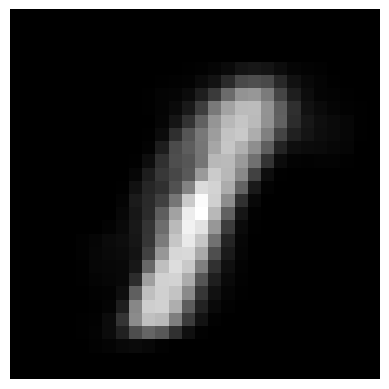

In [77]:
import matplotlib.pyplot as plt

plt.imshow(new_image[0, :, :, 0], cmap="gray")
plt.axis("off")
plt.show()

1/1 [==============================] - 0s 24ms/step


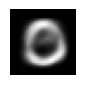

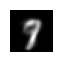

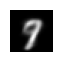

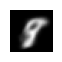

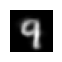

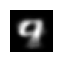

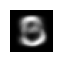

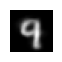

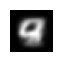

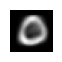

In [79]:
#Generating New Images 

import matplotlib.pyplot as plt 

#Sample random points
z_sample=np.random.normal(size=(10,latend_dim))

generated=decoder.predict(z_sample)

plt.figure(figsize=(10,2))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(generated[i].reshape(28,28),cmap='gray')
    plt.axis('off')
    plt.show()